In [1]:

# ==============================================================
# Libraries
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import treecorr

In [ ]:
# ==============================================================
# Real FRB Catalog Loader
# ==============================================================

def load_frb_catalog(filepath, use_footprint=False):
   
    df = pd.read_csv(filepath)

    # Keep only the coordinate columns needed
    df = df[["RA", "DEC"]].dropna()

    # Remove invalid coordinates
    valid = (df["RA"] >= 0) & (df["RA"] < 360) & \
            (df["DEC"] >= -90) & (df["DEC"] <= 90)

    n_dropped = (~valid).sum()
    if n_dropped > 0:
        print(f"[load_frb_catalog] Dropped {n_dropped} rows with invalid coordinates.")

    df = df[valid].reset_index(drop=True)

    # ----------------------------------------------------------
    # Footprint handling
    # ----------------------------------------------------------

    if use_footprint:
        dec_min = float(np.percentile(df["DEC"], 5))
        dec_max = float(df["DEC"].max())

        print("[load_frb_catalog] Using estimated survey footprint.")

    else:
        dec_min = -90.0
        dec_max = 90.0

        print("[load_frb_catalog] Using full-sky assumption (no footprint).")

    print(f"[load_frb_catalog] Loaded {len(df)} FRBs.")
    print(f"[load_frb_catalog] DEC range used: [{dec_min:.2f}°, {dec_max:.2f}°]")

    return df, dec_min, dec_max

In [ ]:
# ==============================================================
# Catalog Generators (Isotropic and Dipolar)
# ==============================================================
 
def generate_catalog(n_sources, A=0.0, direction=(0, 0),
                     dec_min=-90.0, dec_max=90.0, seed=None):

    
    rng = np.random.default_rng(seed)
 

    sin_min = np.sin(np.deg2rad(dec_min))
    sin_max = np.sin(np.deg2rad(dec_max))
 
    # --- Isotropic case: direct sampling within footprint ---
    if A == 0:
        ra  = 360.0 * rng.random(n_sources)
        u   = rng.uniform(sin_min, sin_max, n_sources)
        dec = np.degrees(np.arcsin(u))
        return pd.DataFrame({"RA": ra, "DEC": dec})
 
    # --- Dipole case: rejection sampling within footprint ---
    ra_d, dec_d = np.deg2rad(direction)
    d = np.array([
        np.cos(dec_d) * np.cos(ra_d),
        np.cos(dec_d) * np.sin(ra_d),
        np.sin(dec_d)
    ])
 
    ra_out, dec_out = [], []
 
    while len(ra_out) < n_sources:
        ra_try  = 360.0 * rng.random()
        u       = rng.uniform(sin_min, sin_max)
        dec_try = np.degrees(np.arcsin(u))
 
        phi   = np.deg2rad(ra_try)
        theta = np.deg2rad(dec_try)
        n = np.array([
            np.cos(theta) * np.cos(phi),
            np.cos(theta) * np.sin(phi),
            np.sin(theta)
        ])
 
        p = (1.0 + A * np.dot(n, d)) / (1.0 + abs(A))
        if rng.random() < p:
            ra_out.append(ra_try)
            dec_out.append(dec_try)
 
    return pd.DataFrame({"RA": ra_out, "DEC": dec_out})

In [ ]:
# ==============================================================
# 2pACF Calculation via TreeCorr (Landy-Szalay Estimator)
# ==============================================================
 
def get_2pacf(df_data, df_rand, min_sep=0.1, max_sep=180.0, nbins=20):
 
    
    cat = treecorr.Catalog(
        ra=df_data["RA"], dec=df_data["DEC"],
        ra_units="deg", dec_units="deg"
    )
    rnd = treecorr.Catalog(
        ra=df_rand["RA"], dec=df_rand["DEC"],
        ra_units="deg", dec_units="deg"
    )
 
    # TreeCorr's default bin_slop is intentional and statistically correct —
    # it must not be altered. Fixed geometric centers are used for the x-axis
    # to ensure consistency across catalogs (see return statement).
    config = dict(min_sep=min_sep, max_sep=max_sep, nbins=nbins, sep_units="deg")
    nn = treecorr.NNCorrelation(**config)
    rr = treecorr.NNCorrelation(**config)
    dr = treecorr.NNCorrelation(**config)
 
    nn.process(cat)
    rr.process(rnd)
    dr.process(cat, rnd)
 
    nn.calculateXi(rr=rr, dr=dr)
 
    # Fixed geometric bin centers derived purely from the bin configuration.
    # exp(meanlogr) shifts slightly between catalogs due to bin_slop; these
    # deterministic centers give a stable shared x-axis for all comparisons.
    log_edges   = np.linspace(np.log(min_sep), np.log(max_sep), nbins + 1)
    theta_fixed = np.exp(0.5 * (log_edges[:-1] + log_edges[1:]))
    return theta_fixed, nn.xi

In [5]:
# ==============================================================
# Absolute Sum Test with Linear Rebinning
# ==============================================================
 
def get_absolute_sum_bins(theta, w, bin_edges):
    """
    Compresses the noisy 2pACF into a scalar per wide angular bin.
 
    For each bin, the mean of w(θ) is computed (rebinning reduces noise),
    and its absolute value is taken. Under isotropy (H0), the mean should
    be ~0; a large |<w>| signals anisotropy at that angular scale.
 
    Parameters
    ----------
    theta : np.ndarray
        Angular bin centers from the 2pACF (degrees).
    w : np.ndarray
        Correlation function values w(θ).
    bin_edges : np.ndarray
        Edges of the wide linear bins (e.g., [0, 20, 40, ..., 180]).
 
    Returns
    -------
    np.ndarray
        Absolute mean correlation per wide bin.
    """
    
    abs_vals = []
    for i in range(len(bin_edges) - 1):
        mask = (theta >= bin_edges[i]) & (theta < bin_edges[i + 1])
        if np.any(mask):
            abs_vals.append(np.abs(np.mean(w[mask])))
        else:
            abs_vals.append(0.0)
    return np.array(abs_vals)

In [6]:
# ==============================================================
# Configuration
# ==============================================================

# FRB catalog path
CATALOG_PATH   = "/home/brunowesley/projetos/FRB-isotropy-tests/FRB_catalogs/SkyPosition.csv"

# Footprint use
USE_FOOTPRINT  = False     # True = use survey footprint | False = assume full sky

N_RAND_FACTOR  = 10        # Random catalog size = N_RAND_FACTOR * N_obs
N_REALIZATIONS = 500       # Monte Carlo draws for the H0 benchmark

COARSE_BINS    = np.arange(0, 181, 20)
BIN_CENTERS    = 0.5 * (COARSE_BINS[:-1] + COARSE_BINS[1:])


# ==============================================================
# Load Real FRB Catalog
# ==============================================================
 
frb_data, DEC_MIN, DEC_MAX = load_frb_catalog(
    CATALOG_PATH,
    use_footprint=USE_FOOTPRINT
)

N_OBS  = len(frb_data)
N_RAND = N_OBS * N_RAND_FACTOR
 
print(f"\nObserved catalog: {N_OBS} FRBs")
print(f"Random catalog    : {N_RAND} sources  (factor {N_RAND_FACTOR}×)")
print(f"DEC footprint     : [{DEC_MIN:.2f}°, {DEC_MAX:.2f}°]\n")
 
 
# ==============================================================
# Monte Carlo Benchmark: Null Hypothesis (Isotropy within Footprint)
# ==============================================================
 
w_bench   = []
abs_bench = []
 
for i in tqdm(range(N_REALIZATIONS), desc="Building H0 benchmark"):
    # Each pair uses non-overlapping seed ranges to prevent collision.
    # Data seeds  : 0 … N_REALIZATIONS-1
    # Random seeds: N_REALIZATIONS … 2*N_REALIZATIONS-1
    d_iso = generate_catalog(N_OBS,  dec_min=DEC_MIN, dec_max=DEC_MAX, seed=i)
    r_iso = generate_catalog(N_RAND, dec_min=DEC_MIN, dec_max=DEC_MAX,
                             seed=i + N_REALIZATIONS)
 
    theta_bench, w = get_2pacf(d_iso, r_iso)
    w_bench.append(w)
    abs_bench.append(get_absolute_sum_bins(theta_bench, w, COARSE_BINS))
 
w_bench   = np.array(w_bench)    # Shape: (N_REALIZATIONS, nbins)
abs_bench = np.array(abs_bench)  # Shape: (N_REALIZATIONS, n_coarse_bins)
 
 
# ==============================================================
# Observed Signal: Real FRB Catalog
# ==============================================================
 
# The random reference for the real data must also respect the footprint.
# Seed 888 is arbitrary but fixed for reproducibility.
rand_ref = generate_catalog(N_RAND, dec_min=DEC_MIN, dec_max=DEC_MAX, seed=888)
 
theta_obs, w_obs = get_2pacf(frb_data, rand_ref)
abs_obs          = get_absolute_sum_bins(theta_obs, w_obs, COARSE_BINS)
 
 
# ==============================================================
# Statistical Summary: p-values per Coarse Bin
# ==============================================================
 
counts = np.sum(abs_bench > abs_obs, axis=0)
p_values = (1 + counts) / (1 + N_REALIZATIONS)
 
print("\nAbsolute Sum Test — p-values per angular bin:")
for center, pv in zip(BIN_CENTERS, p_values):
    flag = " ← significant" if pv < 0.05 else ""
    print(f"  θ = {center:5.1f}°  |  p = {pv:.3f}{flag}")

[load_frb_catalog] Using full-sky assumption (no footprint).
[load_frb_catalog] Loaded 4489 FRBs.
[load_frb_catalog] DEC range used: [-90.00°, 90.00°]

Observed catalog: 4489 FRBs
Random catalog    : 44890 sources  (factor 10×)
DEC footprint     : [-90.00°, 90.00°]



Building H0 benchmark:   0%|          | 0/500 [00:00<?, ?it/s]


Absolute Sum Test — p-values per angular bin:
  θ =  10.0°  |  p = 0.002 ← significant
  θ =  30.0°  |  p = 0.002 ← significant
  θ =  50.0°  |  p = 0.002 ← significant
  θ =  70.0°  |  p = 0.002 ← significant
  θ =  90.0°  |  p = 0.002 ← significant
  θ = 110.0°  |  p = 0.002 ← significant
  θ = 130.0°  |  p = 0.002 ← significant
  θ = 150.0°  |  p = 0.002 ← significant
  θ = 170.0°  |  p = 0.002 ← significant


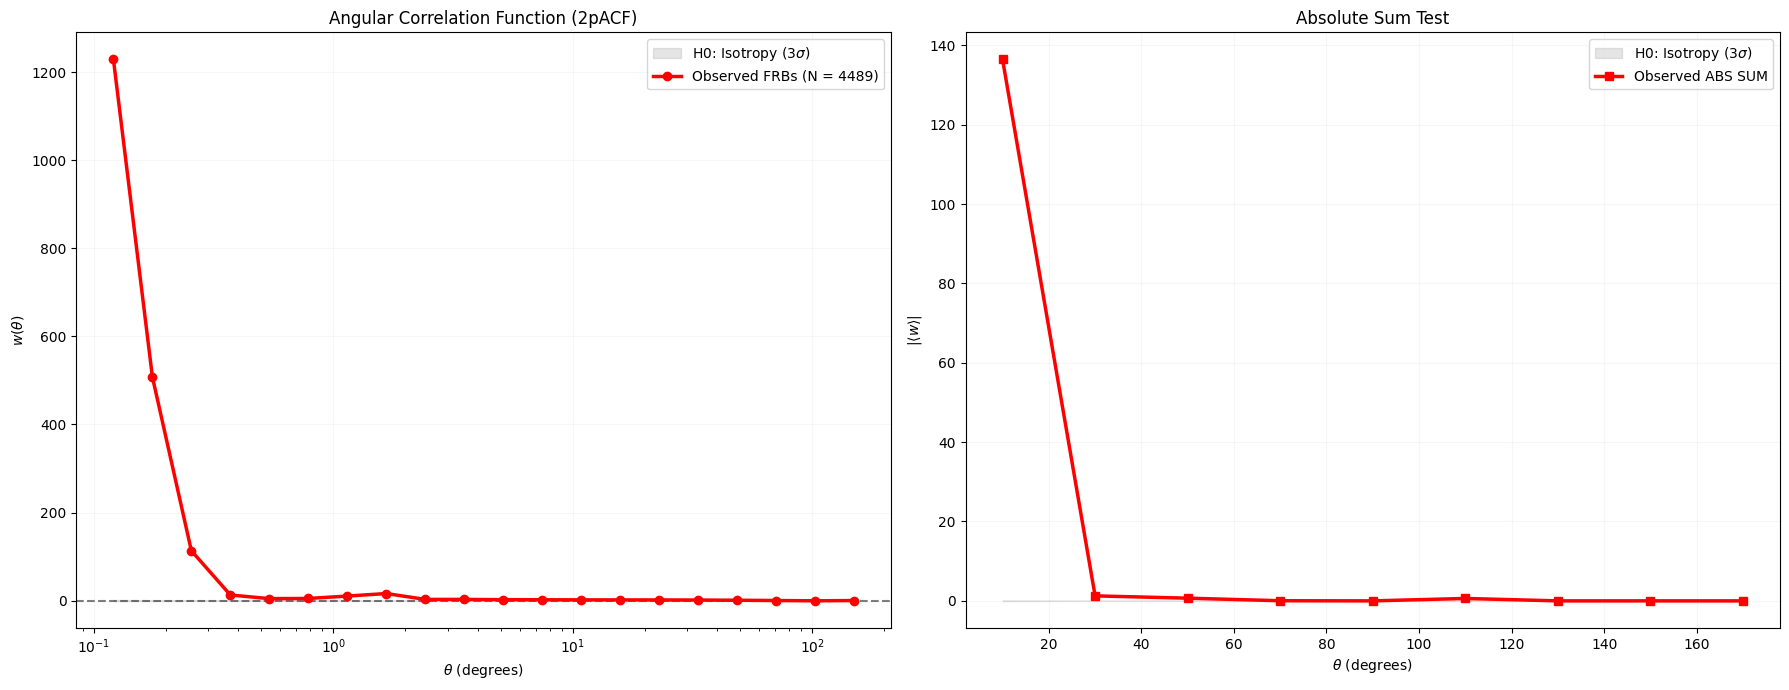

In [7]:
# ==============================================================
# Visualization (styled like ensemble plot)
# ==============================================================

fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# Cores para ensembles (se existirem)
N_ENSEMBLES = 15
colors = plt.cm.viridis(np.linspace(0, 1, N_ENSEMBLES))

# ==============================================================
# --- Plot 1: 2pACF ---
# ==============================================================

# Estatística H0
w_median = np.median(w_bench, axis=0)
w_std    = np.std(w_bench, axis=0)

ax[0].fill_between(
    theta_bench,
    w_median - 3*w_std,
    w_median + 3*w_std,
    color='gray', alpha=0.2,
    label=r'H0: Isotropy ($3\sigma$)'
)

# Se você tiver ensembles individuais (opcional)
if "all_w_obs" in globals():
    for i in range(min(N_ENSEMBLES, len(all_w_obs))):
        lbl = "Individual Ensembles" if i == 0 else ""
        ax[0].plot(theta_obs, all_w_obs[i],
                   color=colors[i], alpha=0.2, lw=1, label=lbl)

# Curva principal (observado)
ax[0].plot(
    theta_obs, w_obs,
    color='red', marker='o', lw=2.5,
    label=f'Observed FRBs (N = {N_OBS})',
    zorder=10
)

ax[0].axhline(0, color='black', ls='--', alpha=0.5)
ax[0].set_xscale('log')
ax[0].set_xlabel(r'$\theta$ (degrees)')
ax[0].set_ylabel(r'$w(\theta)$')
ax[0].set_title('Angular Correlation Function (2pACF)')
ax[0].legend()
ax[0].grid(True, alpha=0.1)


# ==============================================================
# --- Plot 2: Absolute Sum ---
# ==============================================================

# Estatística H0
abs_median = np.median(abs_bench, axis=0)
abs_std    = np.std(abs_bench, axis=0)

ax[1].fill_between(
    BIN_CENTERS,
    abs_median - 3*abs_std,
    abs_median + 3*abs_std,
    color='gray', alpha=0.2,
    label=r'H0: Isotropy ($3\sigma$)'
)

# Ensembles individuais (opcional)
if "all_abs_obs" in globals():
    for i in range(min(N_ENSEMBLES, len(all_abs_obs))):
        lbl = "Individual Ensembles" if i == 0 else ""
        ax[1].plot(BIN_CENTERS, all_abs_obs[i],
                   color=colors[i], alpha=0.2,
                   marker='x', ls=':', label=lbl)

# Curva principal
ax[1].plot(
    BIN_CENTERS, abs_obs,
    color='red', marker='s', lw=2.5,
    label='Observed ABS SUM',
    zorder=10
)

ax[1].set_xlabel(r'$\theta$ (degrees)')
ax[1].set_ylabel(r'$|\langle w \rangle|$')
ax[1].set_title('Absolute Sum Test')
ax[1].legend()
ax[1].grid(True, alpha=0.1)

plt.tight_layout()
plt.savefig("2pACF_FRB_analysis_full.png", dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# ==============================================================
# Table output (Single realization version)
# ==============================================================

# DataFrame com resultado observado
df_abs_results = pd.DataFrame(
    [abs_obs],
    columns=[f"{c:.0f} deg" for c in BIN_CENTERS],
    index=["Observed"]
)

print("\n--- Absolute Sum Test: Observed Data ---")
print(df_abs_results)


# ==============================================================
# Summary statistics vs H0
# ==============================================================

# Estatística do H0
abs_h0_median = np.median(abs_bench, axis=0)
abs_h0_std    = np.std(abs_bench, axis=0)

summary_df = pd.DataFrame({
    "Observed": abs_obs,
    "H0 Median": abs_h0_median,
    "H0 Std": abs_h0_std,
}, index=[f"{c:.0f} deg" for c in BIN_CENTERS])


# --------------------------------------------------------------
# Significance (z-score)
# --------------------------------------------------------------

summary_df["Z-score"] = (
    summary_df["Observed"] - summary_df["H0 Median"]
) / summary_df["H0 Std"]

# Flag de significância
summary_df["Significant (>3σ)"] = np.abs(summary_df["Z-score"]) > 3


# ==============================================================
# Output
# ==============================================================

print("\n--- Absolute Sum Test: Summary vs H0 ---")
print(summary_df.round(4))


# ==============================================================
# Optional: Global metric
# ==============================================================

global_chi2 = np.sum(summary_df["Z-score"]**2)
dof = len(summary_df)

print("\n--- Global Anisotropy Indicator ---")
print(f"Chi2 = {global_chi2:.2f} for {dof} bins")
print(f"Chi2/dof = {global_chi2/dof:.2f}")


--- Absolute Sum Test: Observed Data ---
              10 deg    30 deg    50 deg    70 deg  90 deg   110 deg  130 deg  \
Observed  136.439152  1.257822  0.678963  0.033257     0.0  0.605948      0.0   

          150 deg  170 deg  
Observed      0.0      0.0  

--- Absolute Sum Test: Summary vs H0 ---
         Observed  H0 Median  H0 Std    Z-score  Significant (>3σ)
10 deg   136.4392     0.0259  0.0231  5915.1788               True
30 deg     1.2578     0.0012  0.0009  1351.1682               True
50 deg     0.6790     0.0010  0.0008   849.6577               True
70 deg     0.0333     0.0009  0.0008    41.9336               True
90 deg     0.0000     0.0000  0.0000        NaN              False
110 deg    0.6059     0.0005  0.0004  1418.0471               True
130 deg    0.0000     0.0000  0.0000        NaN              False
150 deg    0.0000     0.0000  0.0000        NaN              False
170 deg    0.0000     0.0000  0.0000        NaN              False

--- Global Anisotropy In